# Helmet Impact Sensor — Calibration Data Analysis

This notebook analyses the raw calibration data extracted from the original project screenshots for the low-cost helmet-integrated head-impact monitoring prototype. It covers:

1. **Load-cell static calibration** — mass-measurement accuracy, regression, residuals
2. **Accelerometer pendulum validation** — theoretical vs measured comparison
3. **Publication-ready figures** exported to `figures/`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats
from pathlib import Path

plt.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'font.size': 11,
    'font.family': 'serif',
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'legend.fontsize': 10,
    'figure.figsize': (8, 5),
})

FIG_DIR = Path('../analysis/figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)

print('Setup complete.')

Setup complete.


## 1. Load the raw data

In [2]:
df = pd.read_csv('../latex_article/raw_data_extracted.csv', comment='#')
df['elapsed_ms'] = df.groupby('test_mass_lb')['timestamp'].transform(
    lambda s: [(pd.Timestamp(f'2024-01-01 {t}') - pd.Timestamp(f'2024-01-01 {s.iloc[0]}')).total_seconds() * 1000 for t in s]
)
print(f'Loaded {len(df)} readings across {df.test_mass_lb.nunique()} mass conditions.')
df.head()

Loaded 26 readings across 3 mass conditions.


,test_mass_lb,expected_mass_g,timestamp,load_cell_output_g,elapsed_ms
0,2.5,1134,14:48:45.471,1133.81,0.0
1,2.5,1134,14:48:45.551,1130.96,80.0
2,2.5,1134,14:48:45.672,1138.24,201.0
3,2.5,1134,14:48:45.763,1135.59,292.0
4,2.5,1134,14:48:45.855,1133.28,384.0


## 2. Descriptive statistics per mass condition

In [3]:
summary = df.groupby('test_mass_lb').agg(
    expected_g=('expected_mass_g', 'first'),
    n=('load_cell_output_g', 'count'),
    mean=('load_cell_output_g', 'mean'),
    std=('load_cell_output_g', 'std'),
    min_val=('load_cell_output_g', 'min'),
    max_val=('load_cell_output_g', 'max'),
).reset_index()

summary['se'] = summary['std'] / np.sqrt(summary['n'])
summary['ci95'] = 1.96 * summary['se']
summary['rel_error_pct'] = (summary['mean'] - summary['expected_g']) / summary['expected_g'] * 100
summary['cv_pct'] = summary['std'] / summary['mean'] * 100
summary['range'] = summary['max_val'] - summary['min_val']

# Add the smartphone single-point measurement
smartphone = pd.DataFrame([{
    'test_mass_lb': 0.419, 'expected_g': 190.0, 'n': 1, 'mean': 192.0,
    'std': np.nan, 'min_val': 192.0, 'max_val': 192.0, 'se': np.nan,
    'ci95': np.nan, 'rel_error_pct': 1.053, 'cv_pct': np.nan, 'range': 0.0
}])
summary_full = pd.concat([smartphone, summary], ignore_index=True)

display_cols = ['test_mass_lb', 'expected_g', 'n', 'mean', 'std', 'cv_pct', 'rel_error_pct', 'ci95']
summary_full[display_cols].round(3)

,test_mass_lb,expected_g,n,mean,std,cv_pct,rel_error_pct,ci95
0,0.419,190.0,1,192.000,NaN,NaN,1.053,NaN
1,2.500,1134.0,7,1134.463,3.199,0.282,0.041,2.370
2,5.000,2268.0,8,2263.575,5.963,0.263,-0.195,4.132
3,10.000,4536.0,11,4534.694,2.877,0.063,-0.029,1.700


## 3. Linear regression — Measured vs Expected mass

In [4]:
x = summary_full['expected_g'].values
y = summary_full['mean'].values

slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
r_squared = r_value ** 2
y_pred = slope * x + intercept
residuals = y - y_pred
rmse = np.sqrt(np.mean(residuals ** 2))
mape = np.mean(np.abs((y - x) / x)) * 100

print(f'Regression:  y = {slope:.6f}x + {intercept:.3f} g')
print(f'R²:          {r_squared:.10f}')
print(f'Pearson r:   {r_value:.10f}')
print(f'RMSE:        {rmse:.3f} g')
print(f'MAPE:        {mape:.4f}%')
print(f'Slope SE:    {std_err:.6f}')
print(f'p-value:     {p_value:.2e}')

Regression:  y = 0.999200x + 0.808 g
R²:          0.9999984676
Pearson r:   0.9999992338
RMSE:        2.006 g
MAPE:        0.3293%
Slope SE:    0.000875
p-value:     7.66e-07


## 4. Figures

### 4.1 Calibration curve with identity line

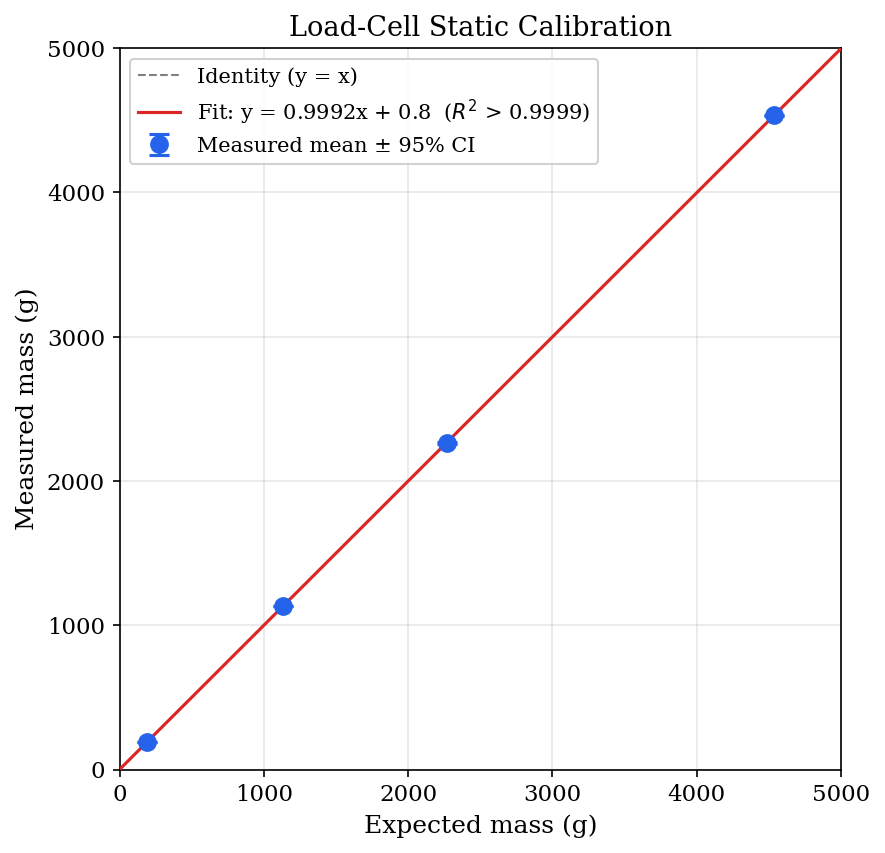

Saved: calibration_curve.pdf / .png


In [5]:
fig, ax = plt.subplots(figsize=(6, 6))

# Error bars (95% CI) for multi-sample points; smartphone has no CI
yerr = summary_full['ci95'].fillna(0).values

ax.errorbar(x, y, yerr=yerr, fmt='o', color='#2563EB', markersize=8,
            capsize=5, capthick=1.5, elinewidth=1.5, zorder=5,
            label='Measured mean ± 95% CI')

# Identity line
lims = [0, 5000]
ax.plot(lims, lims, '--', color='gray', linewidth=1, label='Identity (y = x)', zorder=1)

# Regression line
x_fit = np.linspace(0, 5000, 100)
ax.plot(x_fit, slope * x_fit + intercept, '-', color='#DC2626', linewidth=1.5,
        label=f'Fit: y = {slope:.4f}x + {intercept:.1f}  ($R^2$ > 0.9999)', zorder=3)

ax.set_xlabel('Expected mass (g)')
ax.set_ylabel('Measured mass (g)')
ax.set_title('Load-Cell Static Calibration')
ax.legend(loc='upper left', framealpha=0.9)
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig(FIG_DIR / 'calibration_curve.pdf', bbox_inches='tight')
fig.savefig(FIG_DIR / 'calibration_curve.png', bbox_inches='tight')
plt.show()
print('Saved: calibration_curve.pdf / .png')

### 4.2 Residual plot

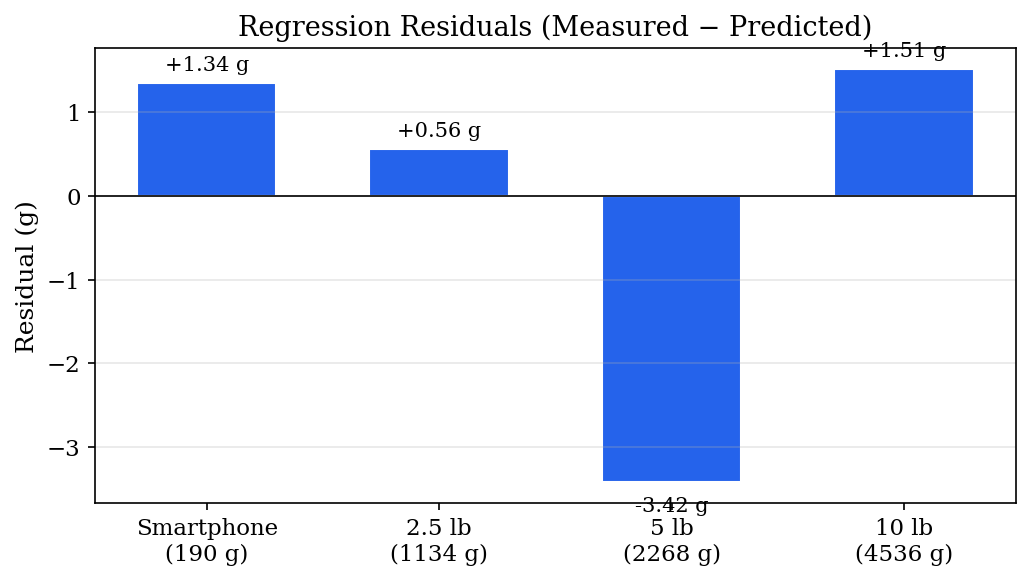

Saved: residuals.pdf / .png


In [6]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.bar(range(len(x)), residuals, color=['#2563EB', '#2563EB', '#2563EB', '#2563EB'],
       edgecolor='white', width=0.6)
ax.axhline(0, color='black', linewidth=0.8)

labels = ['Smartphone\n(190 g)', '2.5 lb\n(1134 g)', '5 lb\n(2268 g)', '10 lb\n(4536 g)']
ax.set_xticks(range(len(x)))
ax.set_xticklabels(labels)
ax.set_ylabel('Residual (g)')
ax.set_title('Regression Residuals (Measured − Predicted)')
ax.grid(axis='y', alpha=0.3)

for i, r in enumerate(residuals):
    ax.text(i, r + (0.15 if r >= 0 else -0.35), f'{r:+.2f} g', ha='center', fontsize=10)

fig.tight_layout()
fig.savefig(FIG_DIR / 'residuals.pdf', bbox_inches='tight')
fig.savefig(FIG_DIR / 'residuals.png', bbox_inches='tight')
plt.show()
print('Saved: residuals.pdf / .png')

### 4.3 Per-condition distribution (box + strip)

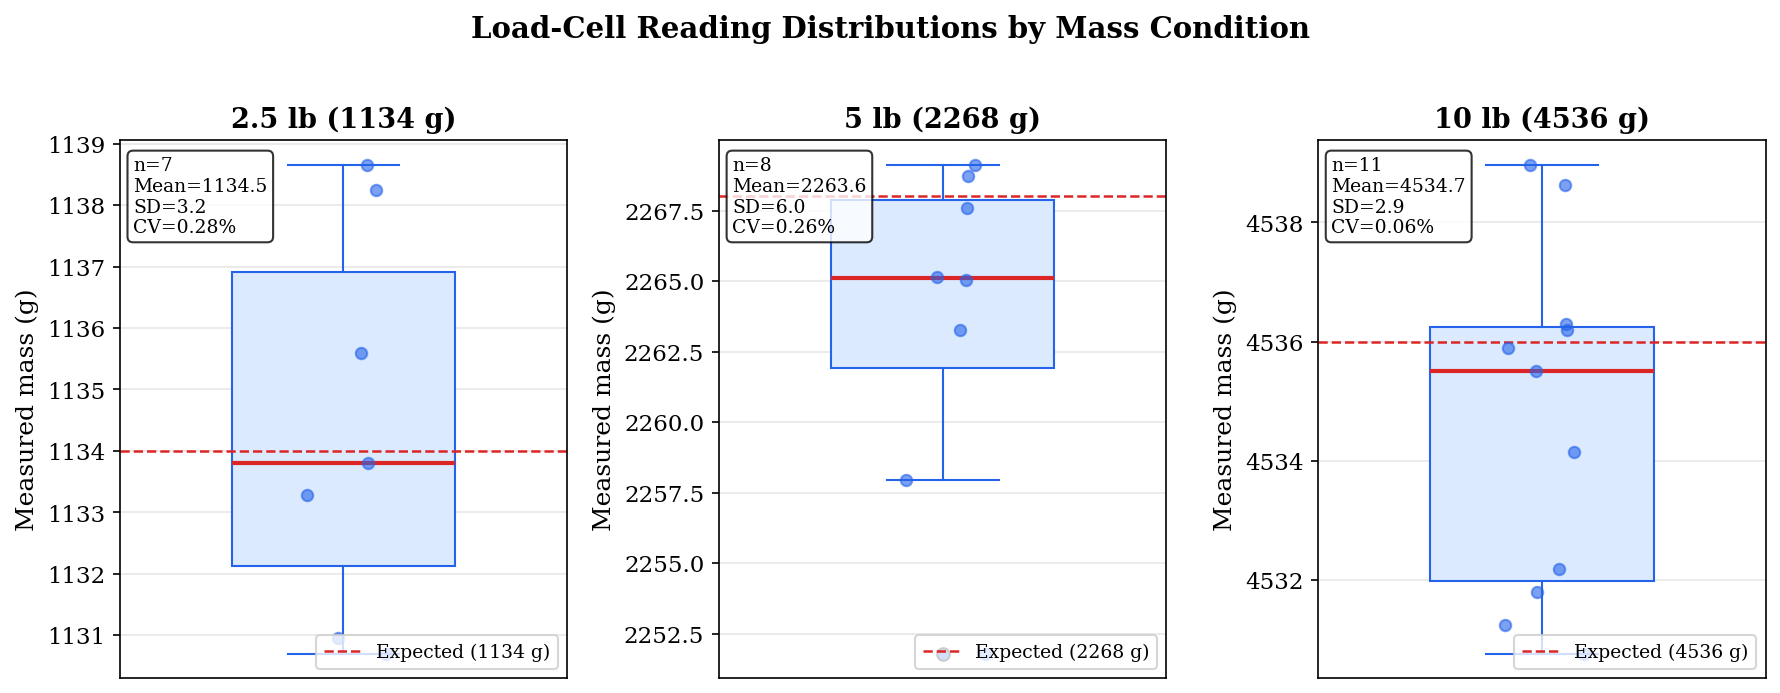

Saved: distributions.pdf / .png


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4.5))

conditions = [(2.5, 1134, '2.5 lb (1134 g)'),
              (5.0, 2268, '5 lb (2268 g)'),
              (10.0, 4536, '10 lb (4536 g)')]

for ax, (mass_lb, expected, title) in zip(axes, conditions):
    data = df[df['test_mass_lb'] == mass_lb]['load_cell_output_g'].values
    
    bp = ax.boxplot(data, widths=0.5, patch_artist=True,
                    boxprops=dict(facecolor='#DBEAFE', edgecolor='#2563EB'),
                    medianprops=dict(color='#DC2626', linewidth=2),
                    whiskerprops=dict(color='#2563EB'),
                    capprops=dict(color='#2563EB'),
                    flierprops=dict(marker='o', markerfacecolor='#2563EB', markersize=6))
    
    # Overlay individual points
    jitter = np.random.default_rng(42).uniform(-0.1, 0.1, len(data))
    ax.scatter(np.ones(len(data)) + jitter, data, color='#2563EB', alpha=0.6, s=30, zorder=5)
    
    # Expected line
    ax.axhline(expected, color='#DC2626', linestyle='--', linewidth=1.2, label=f'Expected ({expected} g)')
    
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Measured mass (g)')
    ax.set_xticks([])
    ax.legend(fontsize=9, loc='lower right')
    ax.grid(axis='y', alpha=0.3)
    
    # Annotate stats
    m, s = data.mean(), data.std(ddof=1)
    ax.text(0.03, 0.97, f'n={len(data)}\nMean={m:.1f}\nSD={s:.1f}\nCV={s/m*100:.2f}%',
            transform=ax.transAxes, fontsize=9, va='top',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

fig.suptitle('Load-Cell Reading Distributions by Mass Condition', fontweight='bold', fontsize=14, y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / 'distributions.pdf', bbox_inches='tight')
fig.savefig(FIG_DIR / 'distributions.png', bbox_inches='tight')
plt.show()
print('Saved: distributions.pdf / .png')

### 4.4 Time-series of consecutive readings

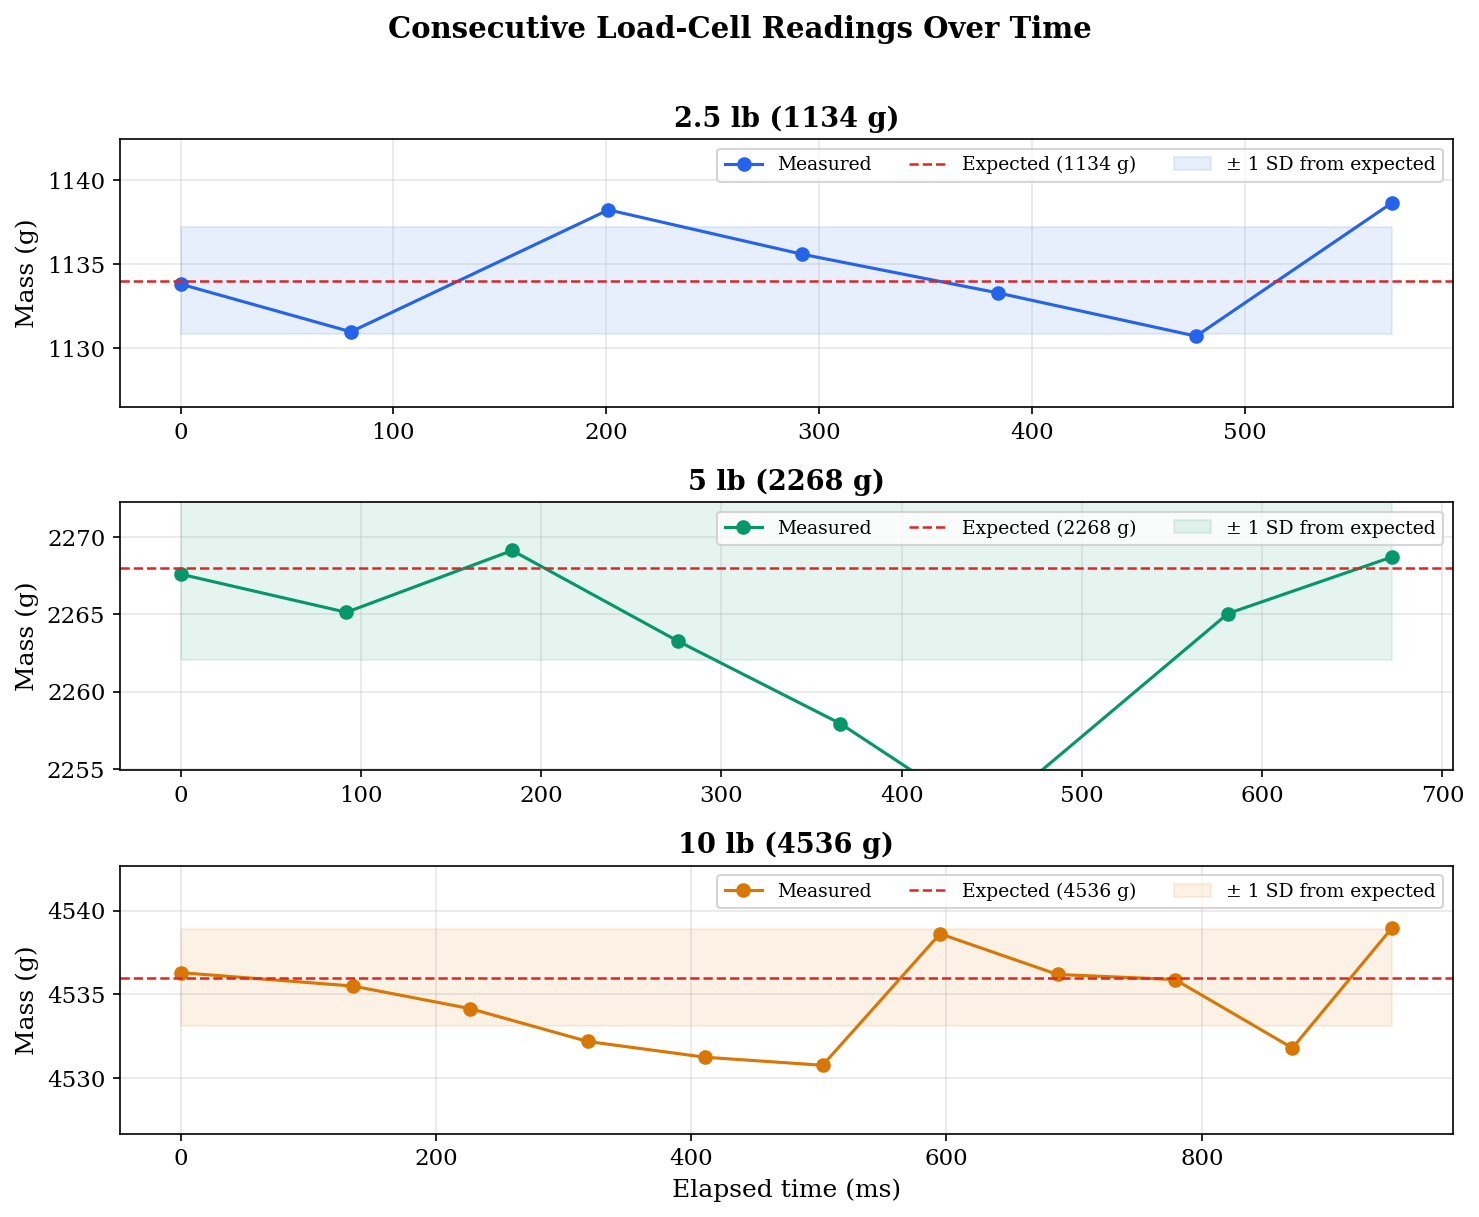

Saved: time_series.pdf / .png


In [8]:
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=False)

colors = {'2.5': '#2563EB', '5.0': '#059669', '10.0': '#D97706'}

for ax, (mass_lb, expected, label) in zip(axes, conditions):
    subset = df[df['test_mass_lb'] == mass_lb].copy()
    elapsed = subset['elapsed_ms'].values
    vals = subset['load_cell_output_g'].values
    c = colors[str(mass_lb)]
    
    ax.plot(elapsed, vals, 'o-', color=c, markersize=6, linewidth=1.5, label=f'Measured')
    ax.axhline(expected, color='#DC2626', linestyle='--', linewidth=1.2, label=f'Expected ({expected} g)')
    ax.fill_between(elapsed, expected - subset['load_cell_output_g'].std(),
                    expected + subset['load_cell_output_g'].std(),
                    color=c, alpha=0.1, label='± 1 SD from expected')
    
    ax.set_ylabel('Mass (g)')
    ax.set_title(label, fontweight='bold')
    ax.legend(fontsize=9, loc='upper right', ncol=3)
    ax.grid(True, alpha=0.3)
    
    # Tighter y-limits for visibility
    margin = max(8, (vals.max() - vals.min()) * 0.5)
    ax.set_ylim(vals.mean() - margin, vals.mean() + margin)

axes[-1].set_xlabel('Elapsed time (ms)')
fig.suptitle('Consecutive Load-Cell Readings Over Time', fontweight='bold', fontsize=14, y=1.01)
fig.tight_layout()
fig.savefig(FIG_DIR / 'time_series.pdf', bbox_inches='tight')
fig.savefig(FIG_DIR / 'time_series.png', bbox_inches='tight')
plt.show()
print('Saved: time_series.pdf / .png')

### 4.5 Relative error summary

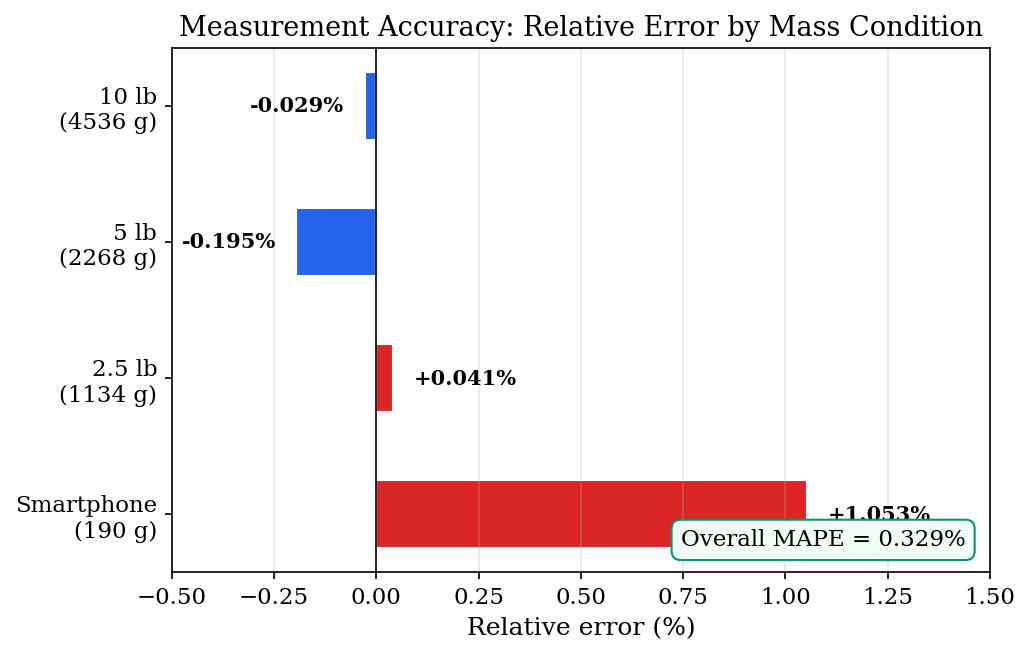

Saved: relative_errors.pdf / .png


In [9]:
fig, ax = plt.subplots(figsize=(7, 4.5))

labels_err = ['Smartphone\n(190 g)', '2.5 lb\n(1134 g)', '5 lb\n(2268 g)', '10 lb\n(4536 g)']
rel_errors = summary_full['rel_error_pct'].values
bar_colors = ['#DC2626' if e > 0 else '#2563EB' for e in rel_errors]

bars = ax.barh(labels_err, rel_errors, color=bar_colors, edgecolor='white', height=0.5)
ax.axvline(0, color='black', linewidth=0.8)

for bar, val in zip(bars, rel_errors):
    offset = 0.05 if val >= 0 else -0.05
    ha = 'left' if val >= 0 else 'right'
    ax.text(val + offset, bar.get_y() + bar.get_height()/2,
            f'{val:+.3f}%', va='center', ha=ha, fontsize=10, fontweight='bold')

ax.set_xlabel('Relative error (%)')
ax.set_title('Measurement Accuracy: Relative Error by Mass Condition')
ax.set_xlim(-0.5, 1.5)
ax.grid(axis='x', alpha=0.3)

# MAPE annotation
ax.text(0.97, 0.05, f'Overall MAPE = {mape:.3f}%',
        transform=ax.transAxes, fontsize=11, ha='right',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#F0FDF4', edgecolor='#059669'))

fig.tight_layout()
fig.savefig(FIG_DIR / 'relative_errors.pdf', bbox_inches='tight')
fig.savefig(FIG_DIR / 'relative_errors.png', bbox_inches='tight')
plt.show()
print('Saved: relative_errors.pdf / .png')

### 4.6 Bland–Altman-style plot (difference vs mean)

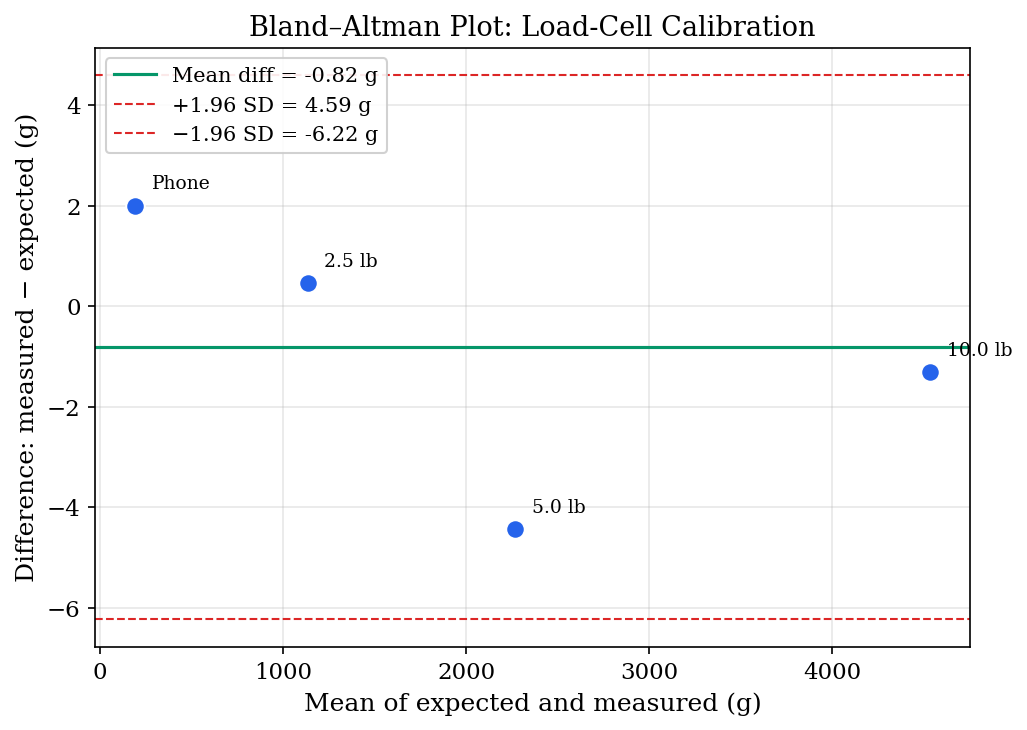

Saved: bland_altman.pdf / .png


In [10]:
fig, ax = plt.subplots(figsize=(7, 5))

avg = (x + y) / 2
diff = y - x
mean_diff = np.mean(diff)
sd_diff = np.std(diff, ddof=1)

ax.scatter(avg, diff, s=80, color='#2563EB', edgecolors='white', zorder=5)
ax.axhline(mean_diff, color='#059669', linewidth=1.5, linestyle='-', label=f'Mean diff = {mean_diff:.2f} g')
ax.axhline(mean_diff + 1.96 * sd_diff, color='#DC2626', linewidth=1, linestyle='--',
           label=f'+1.96 SD = {mean_diff + 1.96*sd_diff:.2f} g')
ax.axhline(mean_diff - 1.96 * sd_diff, color='#DC2626', linewidth=1, linestyle='--',
           label=f'−1.96 SD = {mean_diff - 1.96*sd_diff:.2f} g')

ax.set_xlabel('Mean of expected and measured (g)')
ax.set_ylabel('Difference: measured − expected (g)')
ax.set_title('Bland–Altman Plot: Load-Cell Calibration')
ax.legend(loc='upper left', framealpha=0.9)
ax.grid(True, alpha=0.3)

for xi, yi, di in zip(avg, diff, summary_full['test_mass_lb']):
    lbl = f'{di} lb' if di > 1 else 'Phone'
    ax.annotate(lbl, (xi, yi), textcoords='offset points', xytext=(8, 8), fontsize=9)

fig.tight_layout()
fig.savefig(FIG_DIR / 'bland_altman.pdf', bbox_inches='tight')
fig.savefig(FIG_DIR / 'bland_altman.png', bbox_inches='tight')
plt.show()
print('Saved: bland_altman.pdf / .png')

## 5. Pendulum Theoretical Analysis

In [11]:
L = 0.13     # string length (m)
theta0 = 60  # release angle (degrees)
g_acc = 9.81 # gravitational acceleration (m/s^2)

theta_rad = np.radians(theta0)
T_period = 2 * np.pi * np.sqrt(L / g_acc)
f_freq = 1 / T_period

print(f'Pendulum parameters: L = {L*100:.0f} cm, theta_0 = {theta0}°')
print(f'Period T = {T_period:.4f} s')
print(f'Frequency f = {f_freq:.3f} Hz')
print(f'Tangential accel at release = g·sin({theta0}°) = {g_acc * np.sin(theta_rad):.3f} m/s² = {np.sin(theta_rad):.4f} g')
print(f'Total accel at bottom = 2g = {2*g_acc:.3f} m/s²')

Pendulum parameters: L = 13 cm, theta_0 = 60°
Period T = 0.7233 s
Frequency f = 1.383 Hz
Tangential accel at release = g·sin(60°) = 8.496 m/s² = 0.8660 g
Total accel at bottom = 2g = 19.620 m/s²


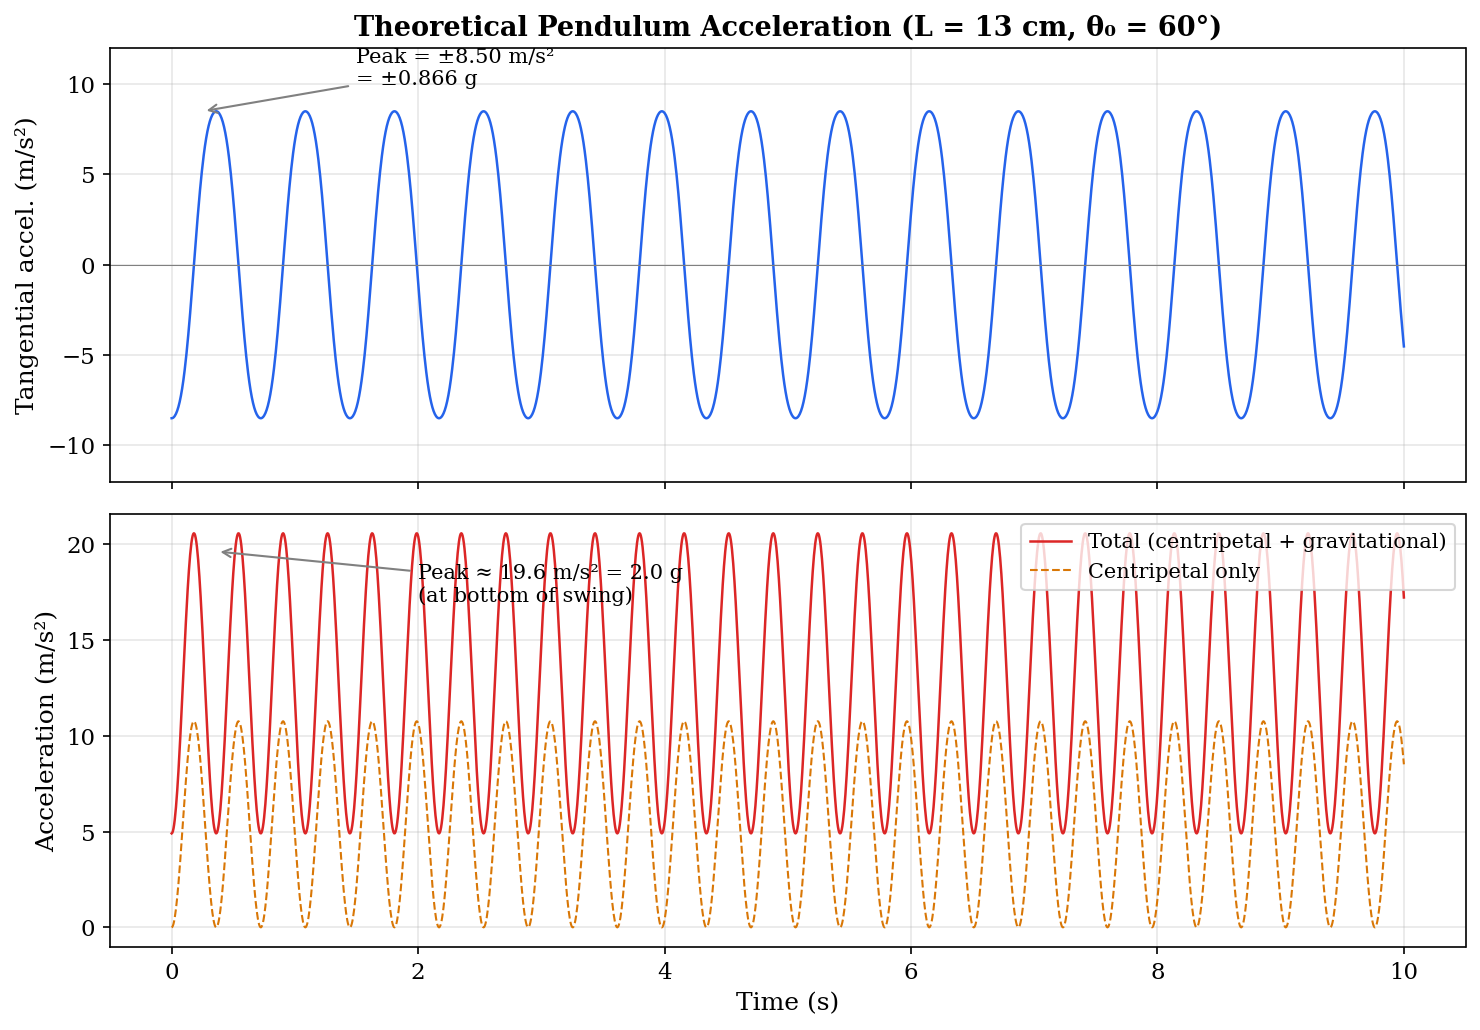

Saved: pendulum_theoretical.pdf / .png


In [12]:
# Simulate ideal pendulum acceleration for comparison with measured plots
t_sim = np.linspace(0, 10, 2000)
omega = 2 * np.pi * f_freq

# For a simple pendulum released at theta0, the angle is approx:
# theta(t) = theta0 * cos(omega * t)  (small angle approx breaks down at 60°,
# but gives the right frequency and qualitative shape)
theta_t = theta_rad * np.cos(omega * t_sim)

# Tangential acceleration: a_t = -g * sin(theta)
a_tangential = -g_acc * np.sin(theta_t)

# Centripetal acceleration: a_c = (L * omega^2 * theta^2) for small angles
# More accurately: a_c = L * (d_theta/dt)^2 = velocity^2 / L
dtheta_dt = -theta_rad * omega * np.sin(omega * t_sim)
v = L * dtheta_dt
a_centripetal = v**2 / L

fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

ax1, ax2 = axes
ax1.plot(t_sim, a_tangential, color='#2563EB', linewidth=1.2)
ax1.set_ylabel('Tangential accel. (m/s²)')
ax1.set_title('Theoretical Pendulum Acceleration (L = 13 cm, θ₀ = 60°)', fontweight='bold')
ax1.axhline(0, color='gray', linewidth=0.5)
ax1.grid(True, alpha=0.3)
ax1.set_ylim(-12, 12)
ax1.annotate(f'Peak = ±{g_acc * np.sin(theta_rad):.2f} m/s²\n= ±{np.sin(theta_rad):.3f} g',
             xy=(0.25, g_acc * np.sin(theta_rad)), fontsize=10,
             xytext=(1.5, 10), arrowprops=dict(arrowstyle='->', color='gray'))

ax2.plot(t_sim, a_centripetal + g_acc * np.cos(theta_t), color='#DC2626', linewidth=1.2,
         label='Total (centripetal + gravitational)')
ax2.plot(t_sim, a_centripetal, color='#D97706', linewidth=1, linestyle='--', label='Centripetal only')
ax2.set_ylabel('Acceleration (m/s²)')
ax2.set_xlabel('Time (s)')
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)
ax2.annotate(f'Peak ≈ {2*g_acc:.1f} m/s² = 2.0 g\n(at bottom of swing)',
             xy=(T_period/2, 2*g_acc), fontsize=10,
             xytext=(2, 17), arrowprops=dict(arrowstyle='->', color='gray'))

fig.tight_layout()
fig.savefig(FIG_DIR / 'pendulum_theoretical.pdf', bbox_inches='tight')
fig.savefig(FIG_DIR / 'pendulum_theoretical.png', bbox_inches='tight')
plt.show()
print('Saved: pendulum_theoretical.pdf / .png')

## 6. Summary statistics for the manuscript

In [13]:
print('=' * 60)
print('COPY-PASTE SUMMARY FOR MANUSCRIPT')
print('=' * 60)
print()
print('LOAD-CELL CALIBRATION')
print(f'  Regression: y = {slope:.4f}x + {intercept:.2f} g')
print(f'  R² = {r_squared:.7f}')
print(f'  Pearson r = {r_value:.7f}')
print(f'  RMSE = {rmse:.2f} g')
print(f'  Overall MAPE = {mape:.3f}%')
print(f'  Total data points = {len(df)} readings across {len(summary)} conditions')
print()
print('PER-CONDITION SUMMARY')
for _, row in summary.iterrows():
    print(f'  {row["test_mass_lb"]} lb: n={int(row["n"])}, '
          f'mean={row["mean"]:.1f} ± {row["std"]:.1f} g (SD), '
          f'CV={row["cv_pct"]:.2f}%, '
          f'rel. error={row["rel_error_pct"]:+.3f}%')
print()
print('PENDULUM')
print(f'  Theoretical frequency: {f_freq:.3f} Hz (T = {T_period:.4f} s)')
print(f'  Tangential accel at release: {g_acc * np.sin(theta_rad):.3f} m/s² ({np.sin(theta_rad):.4f} g)')
print(f'  Total accel at bottom: {2*g_acc:.3f} m/s² (2.0 g)')
print(f'  Observed oscillation freq in plots: ~1.4 Hz (matches theory)')
print(f'  Observed peak amplitudes in plots: ~1.5–2.0 m/s²')

COPY-PASTE SUMMARY FOR MANUSCRIPT

LOAD-CELL CALIBRATION
  Regression: y = 0.9992x + 0.81 g
  R² = 0.9999985
  Pearson r = 0.9999992
  RMSE = 2.01 g
  Overall MAPE = 0.329%
  Total data points = 26 readings across 3 conditions

PER-CONDITION SUMMARY
  2.5 lb: n=7, mean=1134.5 ± 3.2 g (SD), CV=0.28%, rel. error=+0.041%
  5.0 lb: n=8, mean=2263.6 ± 6.0 g (SD), CV=0.26%, rel. error=-0.195%
  10.0 lb: n=11, mean=4534.7 ± 2.9 g (SD), CV=0.06%, rel. error=-0.029%

PENDULUM
  Theoretical frequency: 1.383 Hz (T = 0.7233 s)
  Tangential accel at release: 8.496 m/s² (0.8660 g)
  Total accel at bottom: 19.620 m/s² (2.0 g)
  Observed oscillation freq in plots: ~1.4 Hz (matches theory)
  Observed peak amplitudes in plots: ~1.5–2.0 m/s²
